<a href="https://colab.research.google.com/github/dharshinikumaravel2004-byte/INTERNSHIP-DL/blob/main/cross_entropy_with_kl_divergence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install imblearn


In [ ]:
!pip install seaborn



In [ ]:

!pip install -U tensorflow scikeras imbalanced-learn


In [ ]:
!pip install scikeras



In [ ]:

!pip install -U scikit-learn scikeras tensorflow


  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, matthews_corrcoef

from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import EditedNearestNeighbours

from scikeras.wrappers import KerasClassifier
import tensorflow as tf
from tensorflow.keras.losses import KLDivergence

import warnings
warnings.filterwarnings("ignore")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/mit dataset/mitbih_train.csv"
TEST_PATH  = "/content/drive/MyDrive/mit dataset/mitbih_test.csv"

train = pd.read_csv(TRAIN_PATH, header=None)
test  = pd.read_csv(TEST_PATH, header=None)

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (87554, 188)
Test shape: (21892, 188)


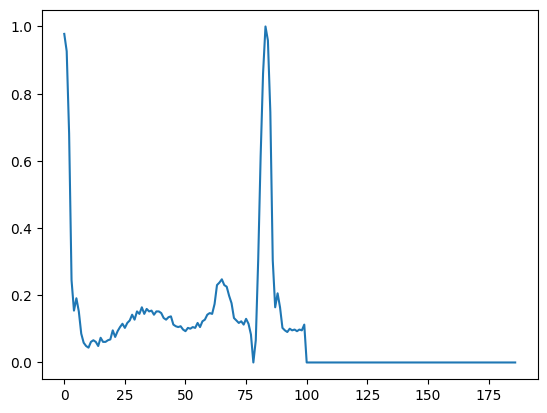

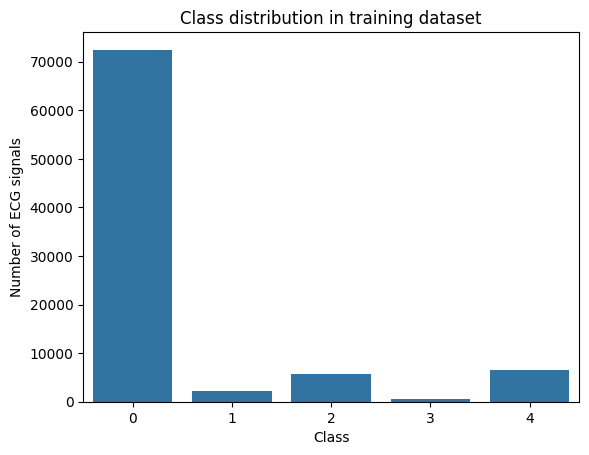

0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64
0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64


In [ ]:
plt.plot(train.iloc[0, train.columns != 187])
plt.show()

counts = train.iloc[:, -1].value_counts().sort_index()
classes = [0, 1, 2, 3, 4]

sns.barplot(x=classes, y=counts.values)
plt.xlabel("Class")
plt.ylabel("Number of ECG signals")
plt.title("Class distribution in training dataset")
plt.show()

print(train.isna().sum())
print(test.isna().sum())


In [ ]:
X_train = train.iloc[:, :-1]
y_train = train.iloc[:, -1]


In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", y_res.value_counts())


After SMOTE: 187
0.0    72471
1.0    72471
2.0    72471
3.0    72471
4.0    72471
Name: count, dtype: int64


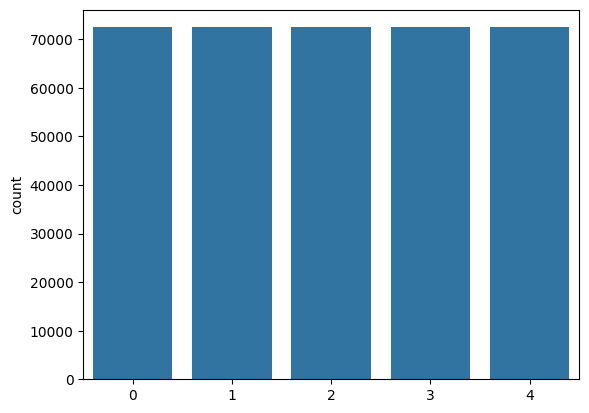

In [ ]:
y_res_cat = to_categorical(y_res, num_classes=5)

sns.barplot(x=classes, y=y_res.value_counts())
plt.show()


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_res, y_res_cat, test_size=0.2, random_state=0
)


In [ ]:
X_test = test.iloc[:, :-1]
y_test = test.iloc[:, -1]
y_test_cat = to_categorical(y_test, num_classes=5)


In [ ]:
def ann_model():
    model = Sequential()
    model.add(Dense(50, input_shape=(187,), activation='relu'))
    model.add(Dense(50, activation='relu'))
    model.add(Dense(5, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss=KLDivergence(),
        metrics=['accuracy']
    )
    return model


In [ ]:
model = ann_model()

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)


Epoch 1/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8151 - loss: 0.5094 - val_accuracy: 0.9195 - val_loss: 0.2203
Epoch 2/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9283 - loss: 0.2006 - val_accuracy: 0.9408 - val_loss: 0.1635
Epoch 3/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.9481 - loss: 0.1487 - val_accuracy: 0.9555 - val_loss: 0.1278
Epoch 4/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - accuracy: 0.9590 - loss: 0.1191 - val_accuracy: 0.9647 - val_loss: 0.1058
Epoch 5/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9664 - loss: 0.0991 - val_accuracy: 0.9660 - val_loss: 0.0953
Epoch 6/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9705 - loss: 0.0868 - val_accuracy: 0.9750 - val_loss: 0.0758
Epoch 7/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9749 - loss: 0.0768 - val_accuracy: 0.9771 - val_loss: 0.0703
Epoch 8/10
4530/4530 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9762 - loss: 0

2265/2265 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
Validation MCC: 0.9761073981161117


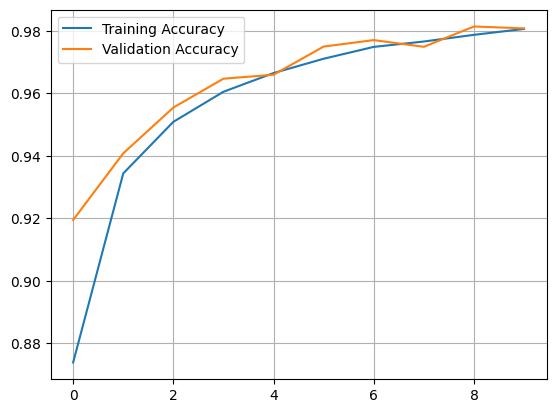

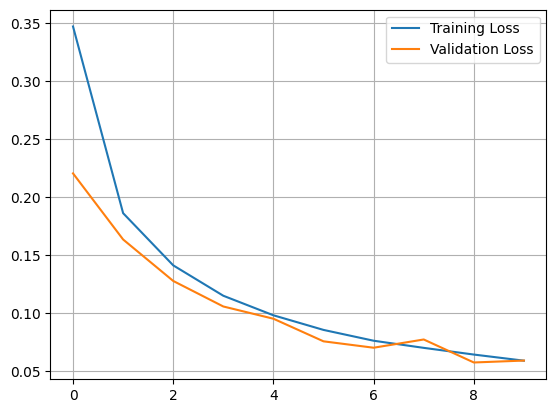

In [ ]:
y_val_pred = np.argmax(model.predict(X_val), axis=1)
y_val_true = np.argmax(y_val, axis=1)

mcc = matthews_corrcoef(y_val_true, y_val_pred)
print("Validation MCC:", mcc)

plt.plot(history.history['accuracy'], label="Training Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.legend()
plt.grid()
plt.show()


685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9442 - loss: 0.1670
Test Accuracy: 0.9427188038825989
Test Loss: 0.19924424588680267
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.94      0.97     18118
         1.0       0.39      0.83      0.53       556
         2.0       0.88      0.94      0.91      1448
         3.0       0.48      0.84      0.61       162
         4.0       0.97      0.97      0.97      1608

    accuracy                           0.94     21892
   macro avg       0.74      0.91      0.80     21892
weighted avg       0.96      0.94      0.95     21892



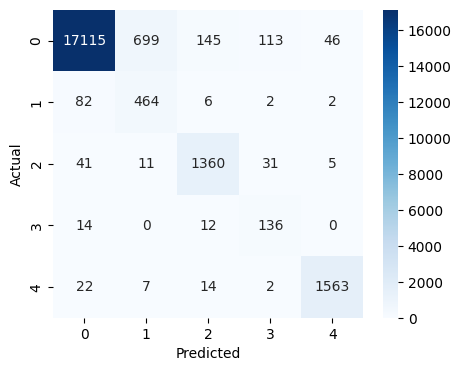

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

y_test_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
estimator = KerasClassifier(
    model=ann_model,
    epochs=10,
    batch_size=64,
    verbose=0
)

kfold = KFold(n_splits=4, shuffle=True, random_state=42)

results = cross_val_score(
    estimator,
    X_res,
    y_res_cat,
    cv=kfold,
    scoring='accuracy'
)

print("Cross-validation scores:", results)
print("Mean CV accuracy:", results.mean())


Cross-validation scores: [0.97765733 0.9767963  0.97360607 0.975935  ]
Mean CV accuracy: 0.9759986751564826
